In [ ]:
import numpy as np
import pandas as pd
import tensorflow as tf
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

In [ ]:
class KNN:
    def __init__(self, nb_features, nb_classes, data, k, weighted=False):
        self.nb_features = nb_features
        self.nb_classes = nb_classes
        self.k = k
        self.weighted = weighted
        self.X = tf.convert_to_tensor(data['x'], dtype=tf.float32)
        self.Y = tf.convert_to_tensor(data['y'], dtype=tf.int32)

    def predict(self, query_data):
        X_query = tf.convert_to_tensor(query_data['x'], dtype=tf.float32)
        Y_query = query_data['y']
        nb_queries = len(X_query)

        matches = 0
        predictions = []

        for i in range(nb_queries):
            dists = tf.norm(self.X - X_query[i], axis=1)
            _, idxs = tf.nn.top_k(-dists, self.k)
            classes = tf.gather(self.Y, idxs)

            if self.weighted:
                weights = 1 / tf.maximum(tf.gather(dists, idxs), 1e-9)
            else:
                weights = tf.fill([self.k], 1.0 / self.k)

            w_col = tf.reshape(weights, (self.k, 1))
            one_hot = tf.one_hot(classes, self.nb_classes)
            scores = tf.reduce_sum(w_col * one_hot, axis=0)
            hyp = tf.argmax(scores)
            predictions.append(hyp.numpy())

            if Y_query is not None and hyp == Y_query[i]:
                matches += 1

        accuracy = matches / nb_queries
        return accuracy, predictions




k=1, accuracy=0.93
k=2, accuracy=0.91
k=3, accuracy=0.96
k=4, accuracy=0.93
k=5, accuracy=0.98
k=6, accuracy=0.93
k=7, accuracy=0.96
k=8, accuracy=0.93
k=9, accuracy=0.96
k=10, accuracy=0.96
k=11, accuracy=0.93
k=12, accuracy=0.93
k=13, accuracy=0.93
k=14, accuracy=0.93
k=15, accuracy=0.96


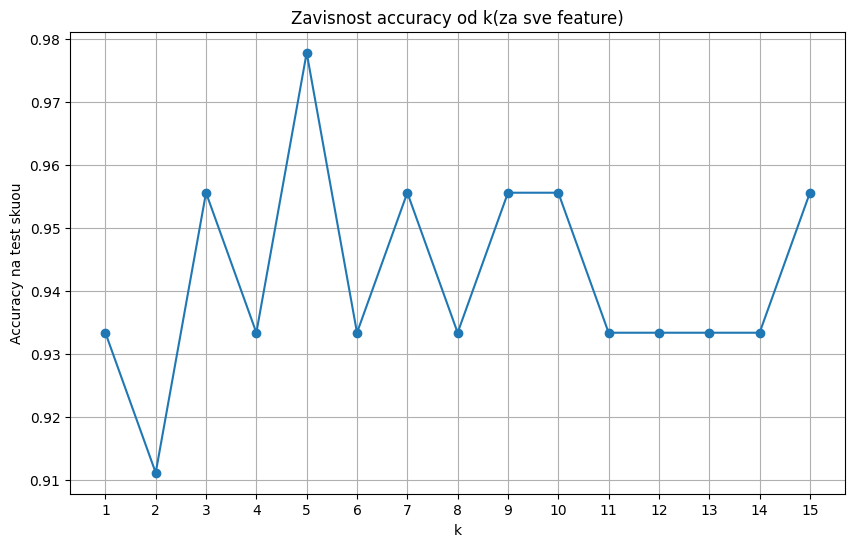

In [ ]:
df = pd.read_csv('iris.csv')
le = LabelEncoder()
df['species'] = le.fit_transform(df['species'])

X = df.iloc[:, :-1].values
y = df['species'].values

X_train, X_test, y_train, y_test = train_test_split(X, y, stratify=y, test_size=0.3, random_state=42)
train_data = {'x': X_train, 'y': y_train}
test_data = {'x': X_test, 'y': y_test}

k_values = list(range(1, 16))
accuracies = []

for k in k_values:
    knn = KNN(nb_features=X.shape[1], nb_classes=3, data=train_data, k=k)
    acc, _ = knn.predict(test_data)
    accuracies.append(acc)
    print(f'k={k}, accuracy={acc:.2f}')

plt.figure(figsize=(10, 6))
plt.plot(k_values, accuracies, marker='o')
plt.title('Zavisnost accuracy od k(za sve feature)')
plt.xlabel('k')
plt.ylabel('Accuracy na test skuou')
plt.xticks(k_values)
plt.grid(True)
plt.show()


U poredjenju sa grafikom koji koristi samo 2 feature-a, ovaj grafik koristi sva 4 i to znatno poboljsava tacnost i stabilnost modela.